
Temel Bileşenler Analizi (PCA - Principal Component Analysis)

Tanım: Çok boyutlu verilerdeki korelasyonları kullanarak,
verideki toplam varyansı (bilgiyi) maksimum düzeyde koruyup
boyut sayısını azaltan (dimensionality reduction) yöntemdir.

Temel Faydaları:
1. Curse of Dimensionality (Boyutlanma Laneti) etkisini azaltır.
2. Model eğitim sürelerini ve hesaplama maliyetini düşürür.
3. Overfitting (Aşırı öğrenme) riskini azaltır.
4. Yüksek boyutlu veriyi 2D / 3D seviyesine indirgeyerek görselleştirme sağlar

 1. Eigenvector (Özvektör - v):

 Verinin yayıldığı (dağıldığı) DOĞRULTUYU / YÖNÜ temsil eder.
 PCA'da her bir Temel Bileşen (Principal Component) bir eigenvector'dür.
 Bu yönler birbirine diktir (orthogonal) yani aralarında korelasyon yoktur.

2. Eigenvalue (Özdeğer - lambda):

Eigenvector yönündeki yayılmanın (VARYANSIN / BİLGİNİN) MİKTARIDIR.
Eigenvalue ne kadar büyükse, o doğrultudaki bilgi (varyans) o kadar fazladır.
Temel bileşenler, Eigenvalue değerlerine göre büyükten küçüğe sıralanır.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer(as_frame=True)

In [4]:
df = data.frame

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
df.shape

(569, 31)

In [7]:
data.DESCR # datamiz hakinda bize bilgi veriyor nereden alinis ozellikleri ney falan filan

'.. _breast_cancer_dataset:\n\nBreast cancer wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 569\n\n:Number of Attributes: 30 numeric, predictive attributes and the class\n\n:Attribute Information:\n    - radius (mean of distances from center to points on the perimeter)\n    - texture (standard deviation of gray-scale values)\n    - perimeter\n    - area\n    - smoothness (local variation in radius lengths)\n    - compactness (perimeter^2 / area - 1.0)\n    - concavity (severity of concave portions of the contour)\n    - concave points (number of concave portions of the contour)\n    - symmetry\n    - fractal dimension ("coastline approximation" - 1)\n\n    The mean, standard error, and "worst" or largest (mean of the three\n    worst/largest values) of these features were computed for each image,\n    resulting in 30 features.  For instance, field 0 is Mean Radius, field\n    10 is Radius SE, field 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [9]:
X = df.drop('target',axis=1)
y = df['target']

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size=0.25,random_state=15)

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
columns = data.feature_names

In [15]:
X_train = pd.DataFrame(X_train,columns=columns)

In [16]:
X_test = pd.DataFrame(X_test,columns=columns)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [18]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

In [19]:
logistic.fit(X_train,y_train)
gbc.fit(X_train,y_train)

GradientBoostingClassifier()

In [20]:
from sklearn . metrics import accuracy_score,confusion_matrix,classification_report

In [21]:
print('logistic regresyon')

y_pred = logistic.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print('--------------------------------')

y_pred_gbc = gbc.predict(X_test)
print(accuracy_score(y_test,y_pred_gbc))
print(confusion_matrix(y_test,y_pred_gbc))
print(classification_report(y_test,y_pred_gbc))

logistic regresyon
0.958041958041958
[[49  4]
 [ 2 88]]
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

--------------------------------
0.9440559440559441
[[46  7]
 [ 1 89]]
              precision    recall  f1-score   support

           0       0.98      0.87      0.92        53
           1       0.93      0.99      0.96        90

    accuracy                           0.94       143
   macro avg       0.95      0.93      0.94       143
weighted avg       0.95      0.94      0.94       143



PCA

In [22]:
from sklearn.decomposition import PCA

In [23]:
pca = PCA(n_components=2)

In [24]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [25]:
X_train_pca = pd.DataFrame(X_train_pca,columns=['PCA 1','PCA 2'])
X_test_pca = pd.DataFrame(X_test_pca,columns=['PCA 1','PCA 2'])

In [26]:
X_train_pca

,PCA 1,PCA 2
0,-0.478413,-0.480238
1,-3.476482,-2.219422
2,-3.054738,-2.309091
3,1.628649,2.254628
4,1.231041,-1.899407
...,...,...
421,3.158756,-1.599216
422,1.182785,0.278223
423,3.986776,-0.321750
424,-2.341799,-1.050465


30 tane kolonumuzu 2 tane kolona indirdik gorsellistir ve calismamiz artik daha kolay bir hale geldi 

In [28]:
logistic.fit(X_train_pca,y_train)
gbc.fit(X_train_pca,y_train)

GradientBoostingClassifier()

In [29]:
print('logistic regresyon')

y_pred = logistic.predict(X_test_pca)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print('--------------------------------')

y_pred_gbc = gbc.predict(X_test_pca)
print(accuracy_score(y_test,y_pred_gbc))
print(confusion_matrix(y_test,y_pred_gbc))
print(classification_report(y_test,y_pred_gbc))

logistic regresyon
0.916083916083916
[[47  6]
 [ 6 84]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        53
           1       0.93      0.93      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143

--------------------------------
0.8811188811188811
[[45  8]
 [ 9 81]]
              precision    recall  f1-score   support

           0       0.83      0.85      0.84        53
           1       0.91      0.90      0.91        90

    accuracy                           0.88       143
   macro avg       0.87      0.87      0.87       143
weighted avg       0.88      0.88      0.88       143



In [36]:
pca = PCA(n_components=4)

In [37]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [38]:
X_train_pca = pd.DataFrame(X_train_pca,columns=['PCA 1','PCA 2','PCA 3','PCA 4'])
X_test_pca = pd.DataFrame(X_test_pca,columns=['PCA 1','PCA 2','PCA 3','PCA 4'])

In [39]:
X_train_pca

,PCA 1,PCA 2,PCA 3,PCA 4
0,-0.478413,-0.480238,-0.905738,-1.388936
1,-3.476482,-2.219422,0.405915,-1.473204
2,-3.054738,-2.309091,-0.288076,-0.074841
3,1.628649,2.254628,-3.204102,-0.170868
4,1.231041,-1.899407,0.541593,2.300880
...,...,...,...,...
421,3.158756,-1.599216,0.059319,-0.434105
422,1.182785,0.278223,-3.902022,0.533188
423,3.986776,-0.321750,1.385298,-0.654037
424,-2.341799,-1.050465,-0.937970,-1.423930


In [40]:
logistic.fit(X_train_pca,y_train)
gbc.fit(X_train_pca,y_train)

GradientBoostingClassifier()

In [41]:
print('logistic regresyon')

y_pred = logistic.predict(X_test_pca)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print('--------------------------------')

y_pred_gbc = gbc.predict(X_test_pca)
print(accuracy_score(y_test,y_pred_gbc))
print(confusion_matrix(y_test,y_pred_gbc))
print(classification_report(y_test,y_pred_gbc))

logistic regresyon
0.9370629370629371
[[48  5]
 [ 4 86]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        53
           1       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143

--------------------------------
0.916083916083916
[[48  5]
 [ 7 83]]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        53
           1       0.94      0.92      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143



In [50]:
X = df.drop('target',axis=1)

In [51]:
scaler = StandardScaler()

In [52]:
X = scaler.fit_transform(X)

In [53]:
pca = PCA(n_components=2)

In [54]:
X = pca.fit_transform(X)

In [55]:
X = pd.DataFrame(X,columns = ['PC 1','PC 2'])

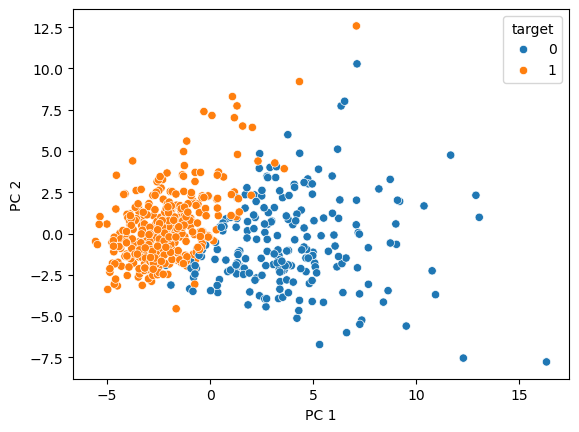

In [56]:
sns.scatterplot(data=X,x='PC 1',y = 'PC 2',hue=df['target'])
plt.show()

PCA HER VERIDE KULLANILMAZ MECBUR OLUNMADIKCA KULLANILMAZ AMA BAZI DATALARDA ISIMIZI COK KOLAYLASTIRI BUNDAN DOLAYI KULLANACAGIMIZ YERLER OLABILIR 